# 32 — v0.6 Outputs Smoke (10 agents × 2 days, gpt-5-mini)

Tiny smoke run whose **only purpose** is to surface every artefact added in the v0.6 outputs expansion (17 → 29 files) so a human can eyeball each one.

**What this notebook does**
1. Builds a 10-citizen sample nation from YouGov.
2. Runs `run_simulation` for **2 alternating package-mode days** with `gpt-5-mini` (OpenAI) handling both messaging and surveys.
3. Calls `save_results` + `save_result_plots` and then inspects, in this order:
   - all CSVs in the run directory (counts, schemas, head)
   - the new bucket-stratified tables (`agent_attributes`, `*_by_bucket`, `day0_vs_dayN_shifts`, `calibration`, `message_flow`)
   - the per-agent diagnostic (`agent_timeline.csv`) for the sampled agents
   - `network_snapshot.json`
   - inline previews of every PNG plot

**Defaults used (all canonical research defaults except size and provider)**
- `communication_mode='package'` over all 6 climate policies
- `day0_anchor='ground_truth_with_rationale'`
- `debias=True`, `thinking=False`, `llm_temperature=0.5`
- `political_message_source='offline'`, set `v1`
- Default exposure (`rule_affinity_rank`, balanced weights, committed-minority symmetric targets)
- Symmetric reach (`reach_a=reach_b=1.0`), no audience cap, `k_peers_per_day=3`
- Default stochastic-block network (`p_intra=0.15`, `p_inter=0.02`)
- Default `timeline_sample_size=3` (one agent per top-3 buckets)
- `random_seed=42`

**Cost / wall-time.** 10 agents × 2 days × 6 policies + day-0 anchoring + debias surveys + reflections + peer messaging is roughly a few hundred `gpt-5-mini` calls. Expect a few minutes of wall time and pennies in API cost.

## 1. Imports + API key

In [1]:
import os, sys, random, logging, time, json
from pathlib import Path

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', force=True)
logging.getLogger('httpx').setLevel(logging.WARNING)
logging.getLogger('openai').setLevel(logging.WARNING)
logging.getLogger('httpcore').setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cag.io.llm import load_api_key
from cag.io.survey import load
from cag.abm.political_messages import load_message_pool, PACKAGE_KEY
from cag.abm.attributes.opinion import ALL_CLIMATE_POLICIES, ClimatePolicyID

API_KEY  = load_api_key('openai', csv_path='../data/api_key.csv')
PROVIDER = 'openai'
MODEL    = 'gpt-5-mini'

print(f'Provider/model : {PROVIDER}/{MODEL}')
print(f'API key loaded : {bool(API_KEY)} (len={len(API_KEY) if API_KEY else 0})')

Provider/model : openai/gpt-5-mini
API key loaded : True (len=164)


## 2. Build a 10-agent SurveyedNation

Same construction as NB17/NB19/NB29, just smaller.

In [2]:
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

N_CITIZENS  = 10
RANDOM_SEED = 42
year = 2026
random.seed(RANDOM_SEED)

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place='UK',
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load('../data/yougov_survey_data/YouGovProcessedData.csv')
data = data.sample(n=N_CITIZENS, random_state=RANDOM_SEED).reset_index(drop=True)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

print(f'Citizens loaded: {len(sn.agents_active)} (target {N_CITIZENS})')

2026-07-01 21:47:49,638 [INFO] Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
2026-07-01 21:47:49,638 [INFO] Column with most NaNs: tprofile_gross_household (398 NaNs)
2026-07-01 21:47:49,641 [INFO] 1483 rows after filtering.


Citizens loaded: 10 (target 10)


## 3. Canonical SIM_CONFIG (every key explicit, override only size + provider)

Every key in `cag.abm.sim.SIM_CONFIG` is listed below.

- `# default` — value equals the source default.
- `# SMOKE OVERRIDE` — size knob (`n_citizens`, `days`).
- `# PROVIDER OVERRIDE` — switched from local Qwen3 to OpenAI `gpt-5-mini` per request.

Everything else matches the v0.6 research-canon defaults.

In [3]:
from cag.abm.sim import SIM_CONFIG

config = {
    # ---- Population --------------------------------------------------------
    'n_citizens'                 : N_CITIZENS,                          # SMOKE OVERRIDE (full=100)

    # ---- Day plan ----------------------------------------------------------
    # 2 alternating package-mode days (P-A first on day 1, P-B first on day 2).
    'days': [                                                           # SMOKE OVERRIDE
        {'phases': ['P-A', 'P-B', 'C']},
        {'phases': ['P-B', 'P-A', 'C']},
    ],

    # ---- Peer messaging ----------------------------------------------------
    'k_peers_per_day'            : 2,                                   # default

    # ---- Network -----------------------------------------------------------
    'network_type'               : 'stochastic_block',                  # default
    'network_params'             : None,                                # default (legacy flat keys below)
    'p_intra'                    : 0.15,                                # default
    'p_inter'                    : 0.05,                                # default
    'block_sizes'                : None,                                # default (auto from politics_id)
    'diagnostics_timeout_s'      : 30.0,                                # default

    # ---- LLM (PROVIDER OVERRIDE: OpenAI gpt-5-mini for both messaging + surveys)
    'llm_model'                  : MODEL,                               # PROVIDER OVERRIDE
    'llm_provider'               : PROVIDER,                            # PROVIDER OVERRIDE
    'llm_temperature'            : 0.5,                                 # default
    'survey_model'               : None,                                # default (use llm_model for surveys too)
    'survey_provider'            : None,                                # default
    'thinking'                   : False,                               # default

    # ---- Communication mode + package policies ----------------------------
    'communication_mode'         : 'package',                           # default
    'package_policies'           : list(ALL_CLIMATE_POLICIES),          # default (ALL six)

    # ---- Political messaging (offline pool = research default) ------------
    'political_message_source'   : 'offline',                           # default
    'political_message_set'      : 'v1',                                # default

    # ---- Day-0 anchoring (research canon) ---------------------------------
    'day0_anchor'                : 'ground_truth_with_rationale',       # default

    # ---- Political-agent reach + audience ---------------------------------
    'reach_a'                    : 1.0,                                 # default
    'reach_b'                    : 1.0,                                 # default
    'audience_cap'               : None,                                # default

    # ---- Political exposure assignment ------------------------------------
    'political_exposure_mode'    : 'rule_affinity_rank',                # default
    'political_exposure_targets' : None,                                # default (committed_minority_symmetric preset)
    'affinity_weights'           : None,                                # default (balanced preset)

    # ---- Agent memory / prompt-assembly (v0.8) ----------------------------
    'memory'                     : 'default',                           # default (reproduces the hard-wired v2 memory)

    # ---- Reproducibility + IO ---------------------------------------------
    'random_seed'                : RANDOM_SEED,                         # default

    # ---- Local-LLM runtime knobs (unused under PROVIDER OVERRIDE) ---------
    'local_base_url'             : None,                                # default
    'local_extra_body'           : None,                                # default
    'local_timeout_s'            : None,                                # default

    # ---- v0.6 timeline sampling -------------------------------------------
    'timeline_sample_size'       : 3,                                   # default (one agent per top-3 buckets)
    'timeline_sample_agent_ids'  : None,                                # default (auto-stratified)
}

# Sanity check: every SIM_CONFIG key is listed here.
missing = sorted(set(SIM_CONFIG) - set(config))
extra   = sorted(set(config)     - set(SIM_CONFIG))
assert not missing, f'NB32 config is missing keys present in SIM_CONFIG: {missing}'
assert not extra,   f'NB32 config has keys not in SIM_CONFIG: {extra}'
print(f'Config has all {len(config)} SIM_CONFIG keys explicit.')

print()
print(f'n_citizens         = {config["n_citizens"]}  (smoke)')
print(f'days               = {len(config["days"])} alternating package-mode days')
print(f'k_peers_per_day    = {config["k_peers_per_day"]}')
print(f'communication_mode = {config["communication_mode"]}')
print(f'package_policies   = ALL {len(config["package_policies"])} climate policies')
print(f'LLM                = {config["llm_provider"]}/{config["llm_model"]}')
print(f'thinking           = {config["thinking"]}, memory = {config["memory"]}')
print(f'day0_anchor        = {config["day0_anchor"]}')
print(f'timeline_sample_size = {config["timeline_sample_size"]}  (auto-stratified by bucket)')
print(f'seed               = {config["random_seed"]}')

Config has all 33 SIM_CONFIG keys explicit.

n_citizens         = 10  (smoke)
days               = 2 alternating package-mode days
k_peers_per_day    = 2
communication_mode = package
package_policies   = ALL 6 climate policies
LLM                = openai/gpt-5-mini
thinking           = False, memory = default
day0_anchor        = ground_truth_with_rationale
timeline_sample_size = 3  (auto-stratified by bucket)
seed               = 42


## 4. Run the simulation

In [4]:
from cag.abm.sim import run_simulation

t0 = time.perf_counter()
results = run_simulation(config, sn)
wall = time.perf_counter() - t0
print(f'\nSimulation complete in {wall/60:.2f} min ({wall:.0f}s)')

2026-07-01 21:54:10,830 [INFO] ===============================================================================
2026-07-01 21:54:10,831 [INFO]                             EXPERIMENT CONFIG
2026-07-01 21:54:10,832 [INFO] ===============================================================================
2026-07-01 21:54:10,832 [INFO] [run-shape]  n_citizens=10  days=2  seed=42  communication_mode=package
2026-07-01 21:54:10,832 [INFO] [exposure]   mode=rule_affinity_rank  targets=None  weights=None  audience_cap=None
2026-07-01 21:54:10,833 [INFO] [broadcast]  reach_a=1.00  reach_b=1.00  message_source=offline  message_set=v1
2026-07-01 21:54:10,833 [INFO] [peer]       k_peers_per_day=2  network_type=stochastic_block  params={p_intra=0.15, p_inter=0.05}
2026-07-01 21:54:10,833 [INFO] [day0]       anchor=ground_truth_with_rationale
2026-07-01 21:54:10,834 [INFO] [llm]        provider=openai  model=gpt-5-mini  temp=0.5  thinking=False
2026-07-01 21:54:10,834 [INFO] [survey-llm] same as [llm]
2


Simulation complete in 14.13 min (848s)


## 5. Save artefacts (CSVs + PNGs + JSON)

`save_results` writes the canonical bundle to a fresh timestamped subdirectory under `data/output/experiments/`. `save_result_plots` writes the standard plot set into the same directory and returns a `{name: path}` mapping.

2026-07-01 22:11:45,323 [INFO] Results saved to ../data/output/experiments/20260701_221142
2026-07-01 22:11:45,807 [INFO] Plot saved to ../data/output/experiments/20260701_221142/opinion_trajectories.png
2026-07-01 22:11:46,138 [INFO] Plot saved to ../data/output/experiments/20260701_221142/opinion_shares.png
2026-07-01 22:11:46,209 [INFO] Plot saved to ../data/output/experiments/20260701_221142/package_index_trajectories.png
2026-07-01 22:11:46,283 [INFO] Plot saved to ../data/output/experiments/20260701_221142/package_index_shares.png
2026-07-01 22:11:46,411 [INFO] Plot saved to ../data/output/experiments/20260701_221142/package_index_by_bucket.png
2026-07-01 22:11:46,895 [INFO] Plot saved to ../data/output/experiments/20260701_221142/opinion_shares_by_bucket.png
2026-07-01 22:11:46,907 [WARNING] gap_widening needs both A-only and B-only buckets; skipping.
2026-07-01 22:11:46,966 [INFO] Plot saved to ../data/output/experiments/20260701_221142/network_graph.png
2026-07-01 22:11:47,248

Artefacts written to:
  ../data/output/experiments/20260701_221142

Plot files:
  opinion_trajectories             -> opinion_trajectories.png
  opinion_shares                   -> opinion_shares.png
  package_index_trajectories       -> package_index_trajectories.png
  package_index_shares             -> package_index_shares.png
  package_index_by_bucket          -> package_index_by_bucket.png
  opinion_shares_by_bucket         -> opinion_shares_by_bucket.png
  network_graph                    -> network_graph.png
  calibration_by_policy            -> calibration_by_policy.png


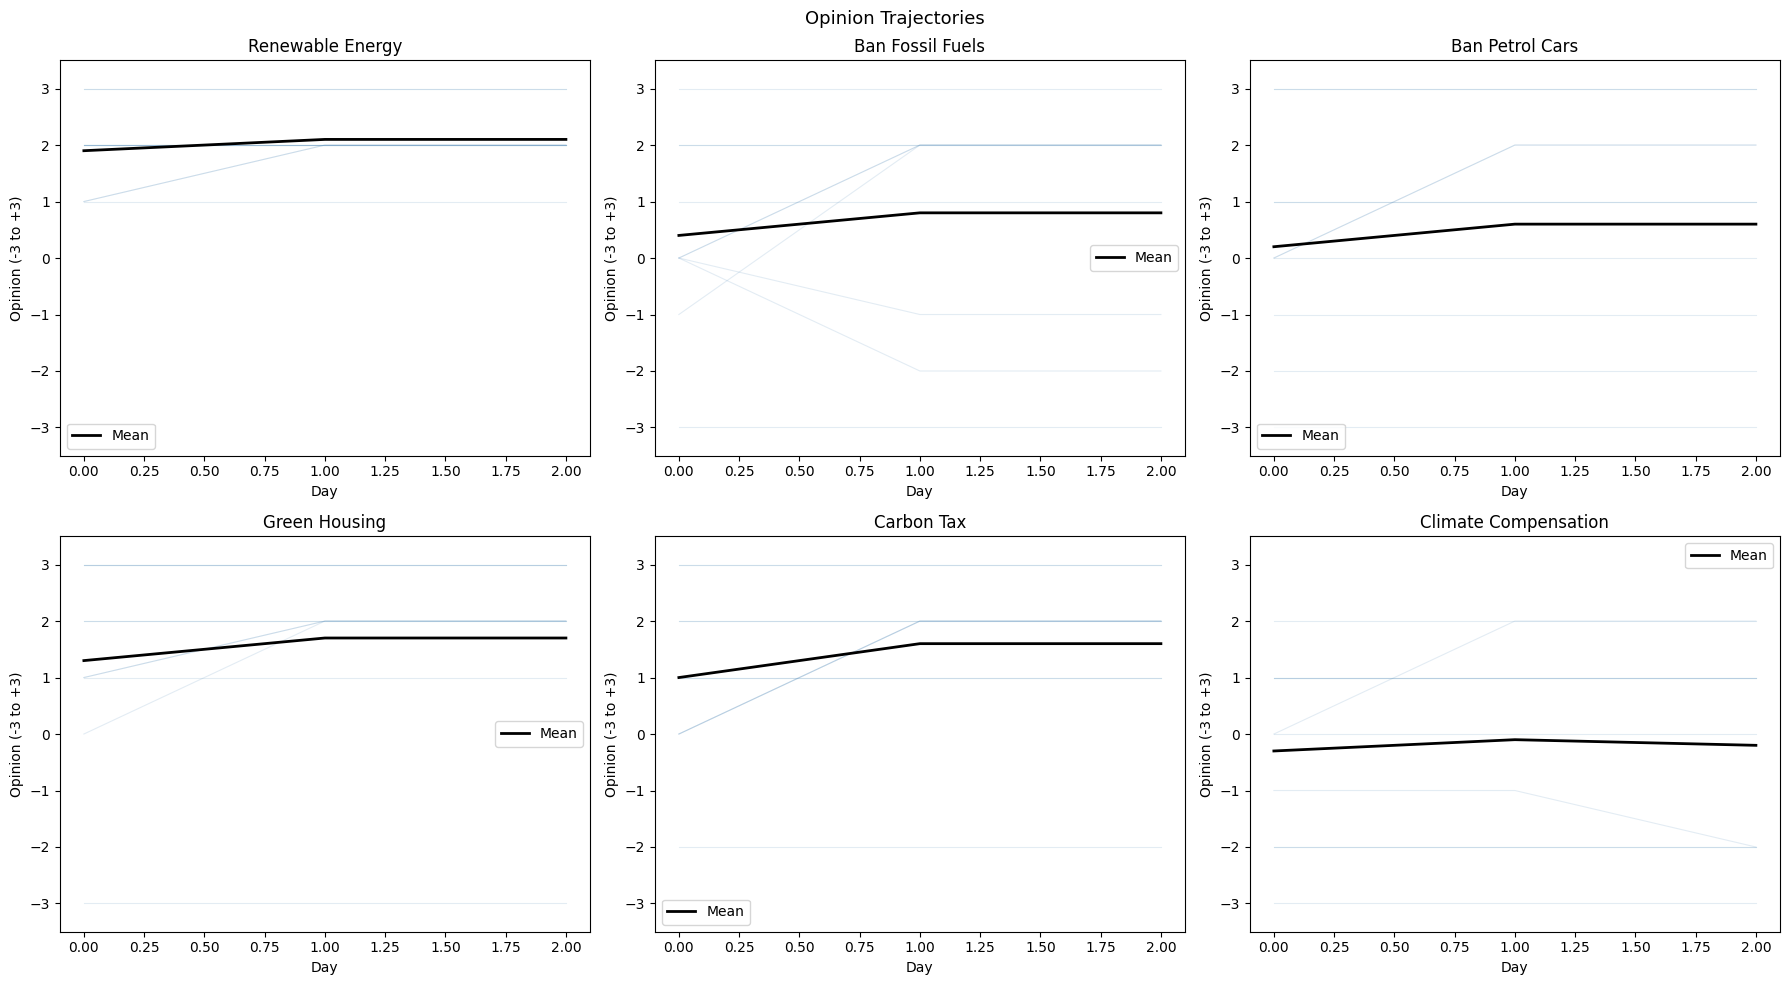

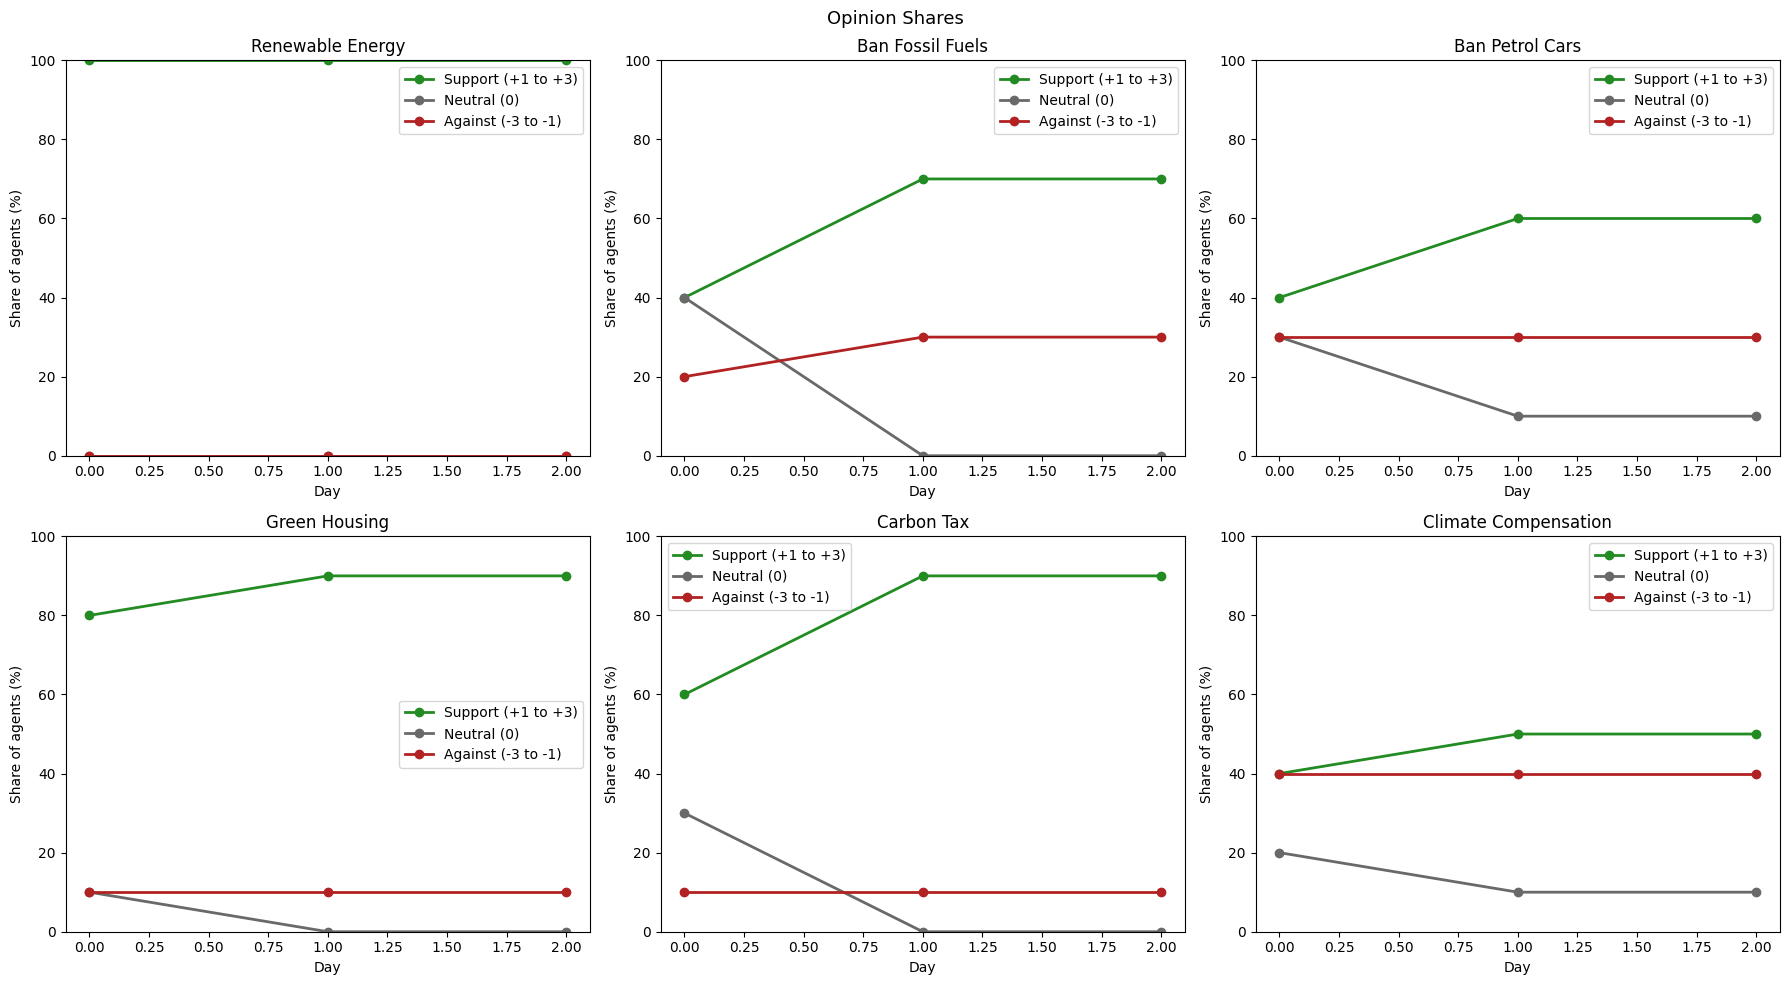

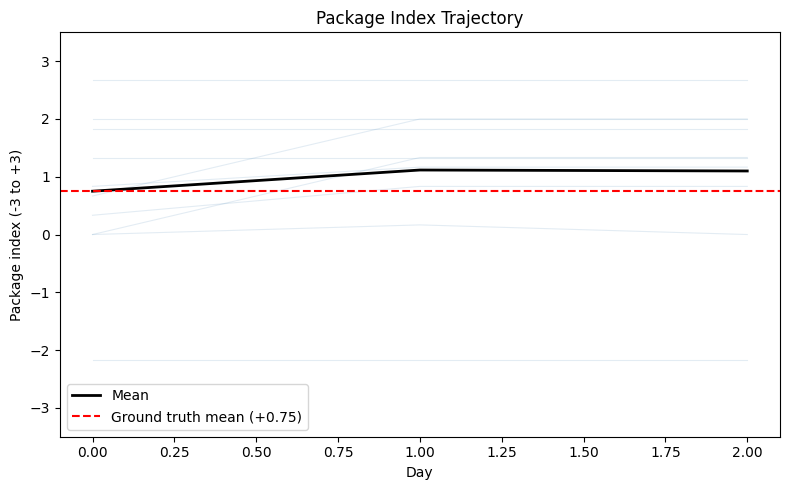

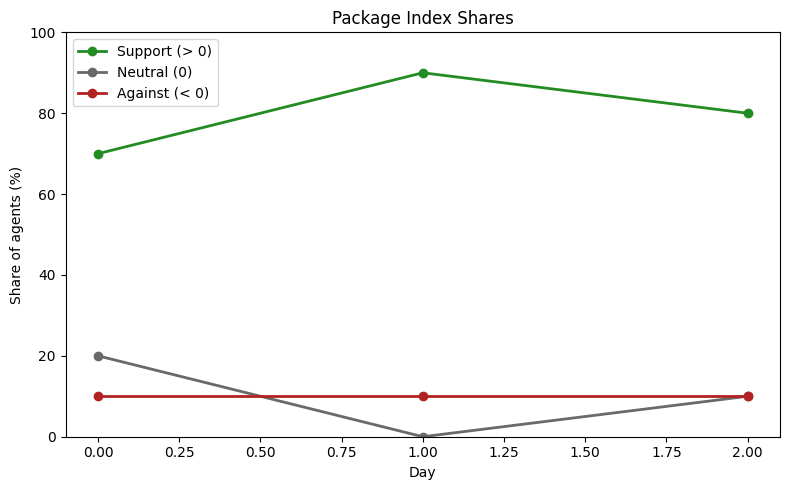

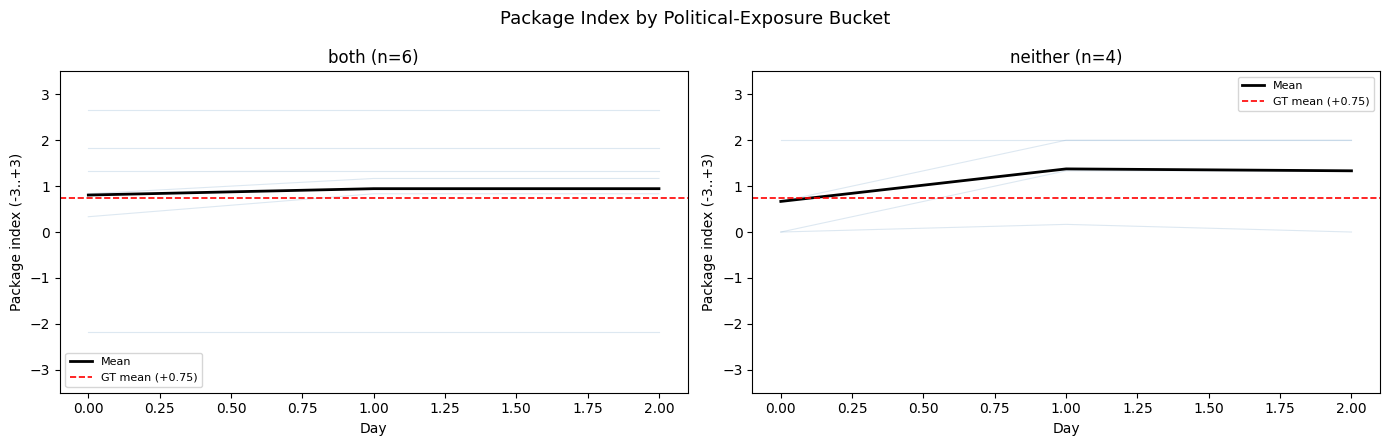

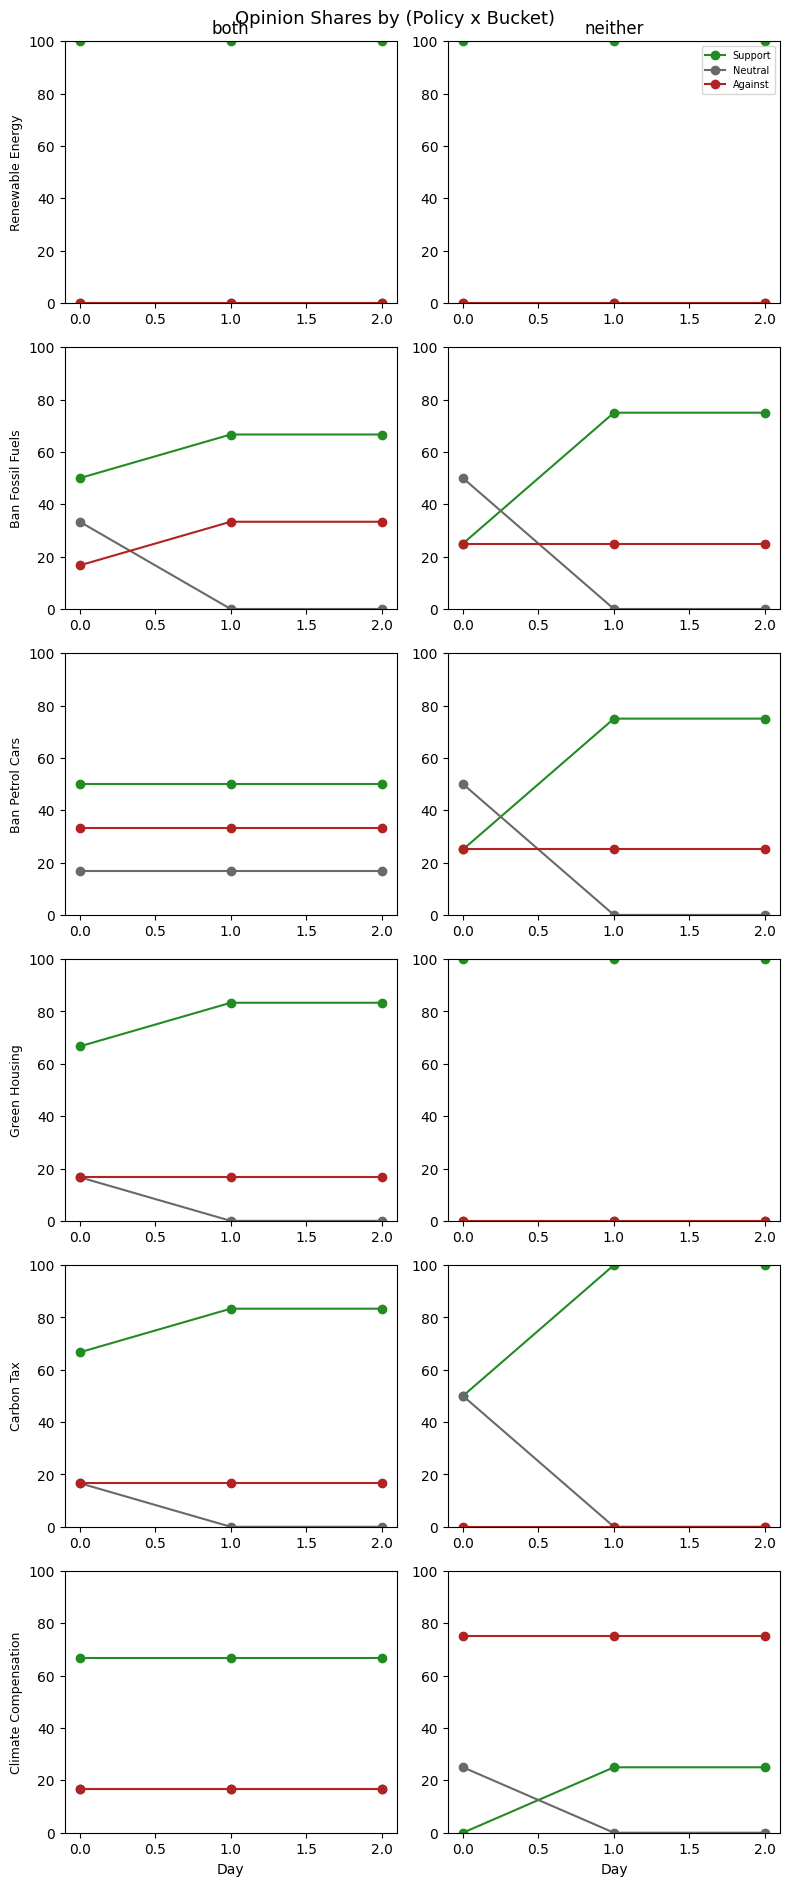

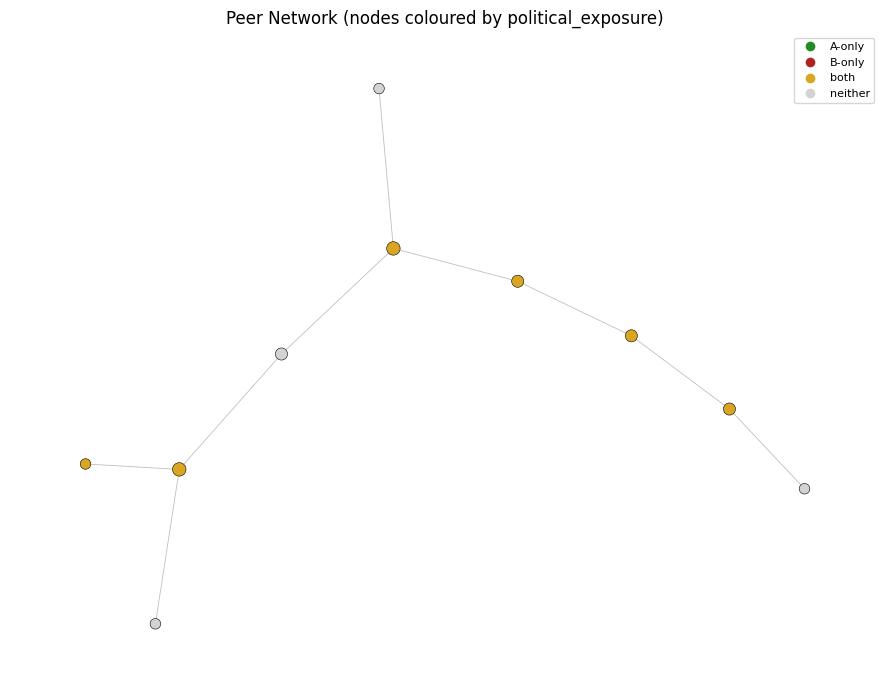

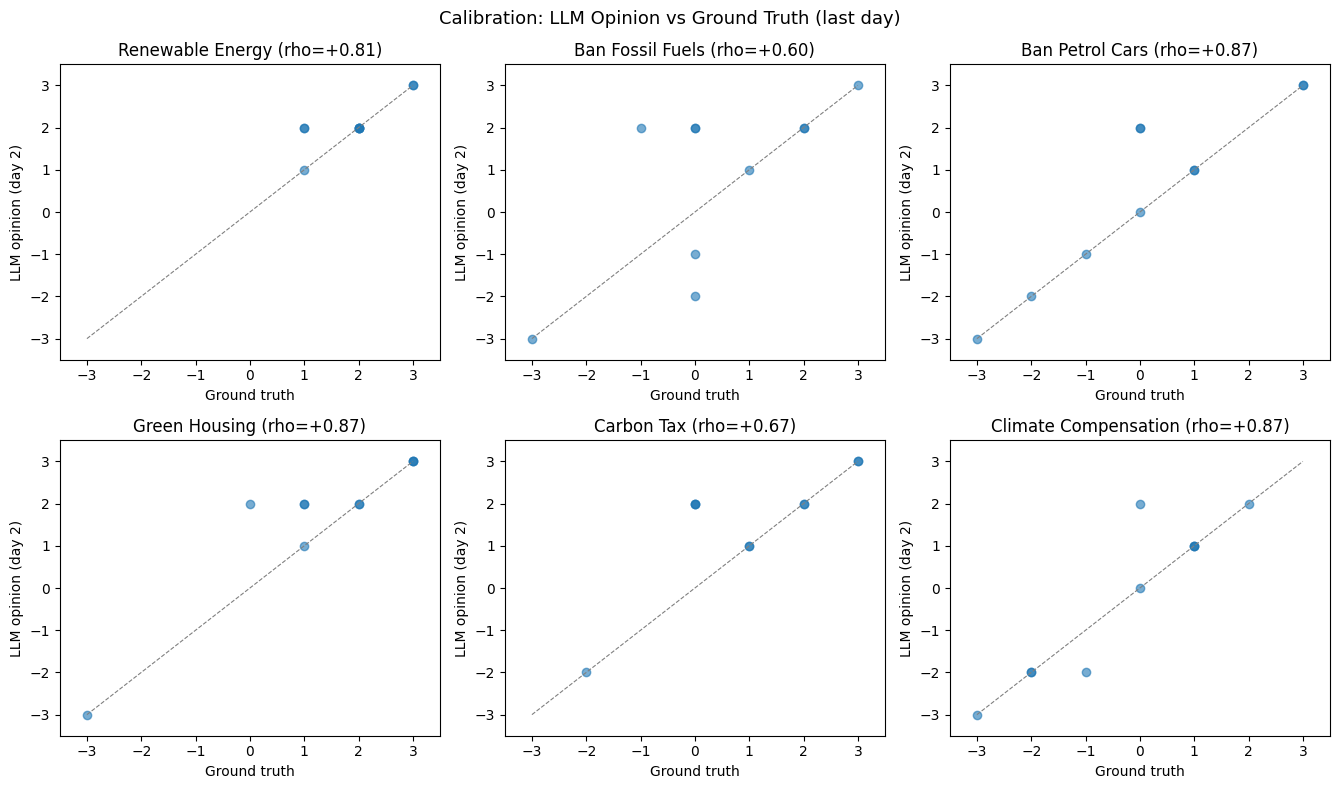

In [5]:
from cag.abm.sim import save_results, save_result_plots

out_path = save_results(results, output_dir='../data/output/experiments')
plot_paths = save_result_plots(results, out_path)

print('Artefacts written to:')
print(' ', out_path)
print('\nPlot files:')
for name, p in plot_paths.items():
    print(f'  {name:32s} -> {p.name}')

## 6. Inventory: every file in the run directory

You should see (modulo empty single-policy frames):

**CSVs (15+):** `opinion_trajectories`, `opinion_shares`, `package_index_trajectories`, `package_index_shares`, `reflections`, `messages`, `survey_reasoning`, `survey_raw_response`, `survey_assembled_context`, `daily_summaries`, `ground_truth`, `package_ground_truth`, `agent_attributes`, `agent_timeline`, `package_index_by_bucket`, `opinion_shares_by_bucket`, `day0_vs_dayN_shifts`, `calibration`, `message_flow`.

**JSON (3):** `config.json`, `network_diagnostics.json`, `network_snapshot.json`.

**PNGs (9):** `opinion_trajectories`, `opinion_shares`, `package_index_trajectories`, `package_index_shares`, `package_index_by_bucket`, `opinion_shares_by_bucket`, `gap_widening`, `network_graph`, `calibration_by_policy`.

In [6]:
out_path = Path(out_path)
all_files = sorted(out_path.iterdir())
inventory = pd.DataFrame([
    {'name': p.name, 'ext': p.suffix, 'size_kb': round(p.stat().st_size / 1024, 1)}
    for p in all_files if p.is_file()
])
print(f'Total files: {len(inventory)}')
inventory

Total files: 30


,name,ext,size_kb
0,agent_attributes.csv,.csv,16.9
1,agent_timeline.csv,.csv,537.9
2,calibration.csv,.csv,1.2
3,calibration_by_policy.png,.png,120.0
4,config.json,.json,1.2
5,daily_summaries.csv,.csv,0.0
6,day0_vs_dayN_shifts.csv,.csv,2.7
7,ground_truth.csv,.csv,1.6
8,message_flow.csv,.csv,0.3
9,messages.csv,.csv,70.6


## 7. CSV row counts + schema preview

Quick sanity table: every CSV with its row count and column list. Empty frames are flagged.

In [7]:
csv_files = sorted(out_path.glob('*.csv'))
rows = []
for p in csv_files:
    try:
        df = pd.read_csv(p)
        rows.append({
            'csv'    : p.name,
            'rows'   : len(df),
            'cols'   : len(df.columns),
            'columns': ', '.join(df.columns),
        })
    except Exception as e:  # noqa: BLE001
        rows.append({'csv': p.name, 'rows': -1, 'cols': -1, 'columns': f'<error: {e}>'})

schema_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 200)
schema_df

,csv,rows,cols,columns
0,agent_attributes.csv,10,11,"agent_id, political_exposure, affinity_score_a, affinity_score_b, year_of_birth, gender_id, region_id, education_id, ukge2019_vote_id, brexit_vote_id, persona_text"
1,agent_timeline.csv,223,11,"agent_id, political_exposure, sim_step, day, phase, event_type, policy_id, counterparty_id, counterparty_role, content, metadata_json"
2,calibration.csv,18,7,"policy_id, day, n, pearson_r, spearman_rho, mae, mean_signed_bias"
3,daily_summaries.csv,0,5,"agent_id, sim_step, day, policy_id, summary"
4,day0_vs_dayN_shifts.csv,60,9,"agent_id, policy_id, political_exposure, day0, dayN, day0_numeric, dayN_numeric, signed_shift, abs_shift"
5,ground_truth.csv,60,3,"agent_id, policy_id, ground_truth"
6,message_flow.csv,8,6,"day, phase, sender_side, recipient_bucket, n_messages, mean_chars"
7,messages.csv,56,14,"sim_step, day, phase, message_type, sender_type, sender_id, sender_side, recipient_id, recipient_scope, policy_id, package_scope, policy_ids_json, message_text, political_message_id"
8,opinion_shares.csv,18,9,"policy_id, day, n_agents, n_support, support_pct, n_neutral, neutral_pct, n_against, against_pct"
9,opinion_shares_by_bucket.csv,36,10,"policy_id, day, political_exposure, n_agents, n_support, n_neutral, n_against, support_pct, neutral_pct, against_pct"


## 8. NEW v0.6 tables — short peek at each one

### 8a. `agent_attributes.csv` — one row per active agent

Persisted once at end-of-run. Contains the `political_exposure` bucket, both affinity scores (now cached on every citizen by `_assign_affinity_rank`), the demographic IDs that drive the persona, and the full `get_persona()` text the LLM saw.

In [12]:
attrs = pd.read_csv(out_path / 'agent_attributes.csv')
print(f'Shape: {attrs.shape}')
print('Bucket counts:')
print(attrs['political_exposure'].value_counts())
attrs.head()

Shape: (10, 11)
Bucket counts:
political_exposure
both       6
neither    4
Name: count, dtype: int64


,agent_id,political_exposure,affinity_score_a,affinity_score_b,year_of_birth,gender_id,region_id,education_id,ukge2019_vote_id,brexit_vote_id,persona_text
0,165.0,both,0.200000,7.800000,1980,1,9,9,1,2,"I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I a..."
1,582.0,neither,4.400000,5.850000,1968,1,2,14,7,3,"I am a 58 year old female living in the North West. My ethnicity is white. I have a Teaching qualification (not degree). My gross household income is £40,000 - £44,999 per year. I am a parent. I p..."
2,1379.0,both,1.533333,7.966667,1977,2,8,17,1,2,"I am a 49 year old male living in the South East. My ethnicity is white. I have a University or CNAA higher degree (e.g. M.Sc, Ph.D). My gross household income is £60,000 - £69,999 per year. I am ..."
3,713.0,both,3.333333,6.916667,1979,1,11,9,6,2,"I am a 47 year old female living in the Scotland. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £45,000 - £49,999 per year. I am ..."
4,1878.0,neither,4.900000,3.100000,1989,2,9,17,7,3,"I am a 37 year old male living in the South West. My ethnicity is white. I have a University or CNAA higher degree (e.g. M.Sc, Ph.D). My gross household income is £50,000 - £59,999 per year. I am ..."


In [13]:
# Persona text for one agent (truncated for display)
sample_persona = attrs.iloc[0]['persona_text']
print(f'agent_id = {attrs.iloc[0]["agent_id"]}')
print(f'persona_text ({len(str(sample_persona))} chars):')
print('---')
print(str(sample_persona)[:1500])
print('---')

agent_id = 165.0
persona_text (1603 chars):
---
I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I am a parent. I voted for the Conservative party candidate in the 2019 General Election. I voted to leave in the 2016 EU Referendum.
When it comes to my core values and worldview: I care about the people close to me and have a basic respect for nature, but I do not actively champion global equality or make environmental protection a primary, driving life focus. I am not strongly driven by the need to get ahead of others, impress people, or hold leadership positions where I tell others what to do. I am moderately curious and will occasionally try new things, but I generally balance this by relying on familiar methods rather than constantly seeking out extreme novelty or risks. I maintain a general respect for elders and standard societal norms, but 

### 8b. `package_index_by_bucket.csv` — package index aggregated per `(day, bucket)`

In [14]:
pkg_by_bucket = pd.read_csv(out_path / 'package_index_by_bucket.csv')
pkg_by_bucket

,day,political_exposure,n_agents,mean,std,q25,q50,q75
0,0,both,6,0.805556,1.664721,0.458333,1.083333,1.708333
1,0,neither,4,0.666667,0.942809,0.000000,0.333333,1.000000
2,1,both,6,0.944444,1.652159,0.916667,1.250000,1.708333
3,1,neither,4,1.375000,0.864688,1.041667,1.666667,2.000000
4,2,both,6,0.944444,1.652159,0.916667,1.250000,1.708333
5,2,neither,4,1.333333,0.942809,1.000000,1.666667,2.000000


### 8c. `opinion_shares_by_bucket.csv` — support/neutral/against shares per `(policy, day, bucket)`

In [15]:
shares_by_bucket = pd.read_csv(out_path / 'opinion_shares_by_bucket.csv')
print(f'Shape: {shares_by_bucket.shape}')
shares_by_bucket.head(20)

Shape: (36, 10)


,policy_id,day,political_exposure,n_agents,n_support,n_neutral,n_against,support_pct,neutral_pct,against_pct
0,ClimatePolicyID(1),0,both,6,6,0,0,100.000000,0.000000,0.000000
1,ClimatePolicyID(1),0,neither,4,4,0,0,100.000000,0.000000,0.000000
2,ClimatePolicyID(1),1,both,6,6,0,0,100.000000,0.000000,0.000000
3,ClimatePolicyID(1),1,neither,4,4,0,0,100.000000,0.000000,0.000000
4,ClimatePolicyID(1),2,both,6,6,0,0,100.000000,0.000000,0.000000
5,ClimatePolicyID(1),2,neither,4,4,0,0,100.000000,0.000000,0.000000
6,ClimatePolicyID(2),0,both,6,3,2,1,50.000000,33.333333,16.666667
7,ClimatePolicyID(2),0,neither,4,1,2,1,25.000000,50.000000,25.000000
8,ClimatePolicyID(2),1,both,6,4,0,2,66.666667,0.000000,33.333333
9,ClimatePolicyID(2),1,neither,4,3,0,1,75.000000,0.000000,25.000000


### 8d. `day0_vs_dayN_shifts.csv` — per `(agent, policy)` signed shift from Day-0 to last day

In [16]:
shifts = pd.read_csv(out_path / 'day0_vs_dayN_shifts.csv')
print(f'Shape: {shifts.shape}')
print(f'Mean signed shift: {shifts["signed_shift"].mean():+.3f}')
print(f'Mean absolute shift: {shifts["abs_shift"].mean():.3f}')
print('\nShift distribution by bucket:')
print(shifts.groupby('political_exposure')['signed_shift'].agg(['count', 'mean', 'std']))
shifts.head()

Shape: (60, 9)
Mean signed shift: +0.350
Mean absolute shift: 0.483

Shift distribution by bucket:
                    count      mean       std
political_exposure                           
both                   36  0.138889  0.592948
neither                24  0.666667  1.167184


,agent_id,policy_id,political_exposure,day0,dayN,day0_numeric,dayN_numeric,signed_shift,abs_shift
0,69.0,ClimatePolicyID(1),neither,0,2,1,2,1,1
1,69.0,ClimatePolicyID(2),neither,0,2,0,2,2,2
2,69.0,ClimatePolicyID(3),neither,0,2,0,2,2,2
3,69.0,ClimatePolicyID(4),neither,0,2,1,2,1,1
4,69.0,ClimatePolicyID(5),neither,0,2,0,2,2,2


### 8e. `calibration.csv` — per `(policy, day)` Pearson / Spearman / MAE vs ground truth

In [17]:
calib = pd.read_csv(out_path / 'calibration.csv')
calib

,policy_id,day,n,pearson_r,spearman_rho,mae,mean_signed_bias
0,ClimatePolicyID(1),0,10,1.000000,1.000000,0.0,0.0
1,ClimatePolicyID(1),1,10,0.822365,0.813250,0.2,0.2
2,ClimatePolicyID(1),2,10,0.822365,0.813250,0.2,0.2
3,ClimatePolicyID(2),0,10,1.000000,1.000000,0.0,0.0
4,ClimatePolicyID(2),1,10,0.691928,0.602280,1.0,0.4
5,ClimatePolicyID(2),2,10,0.691928,0.602280,1.0,0.4
6,ClimatePolicyID(3),0,10,1.000000,1.000000,0.0,0.0
7,ClimatePolicyID(3),1,10,0.913143,0.866081,0.4,0.4
8,ClimatePolicyID(3),2,10,0.913143,0.866081,0.4,0.4
9,ClimatePolicyID(4),0,10,1.000000,1.000000,0.0,0.0


### 8f. `message_flow.csv` — `(day × phase × sender_side × recipient_bucket)` aggregation

In [18]:
flow = pd.read_csv(out_path / 'message_flow.csv')
print(f'Shape: {flow.shape}')
flow

Shape: (8, 6)


,day,phase,sender_side,recipient_bucket,n_messages,mean_chars
0,1,C,NaN,both,12,736.916667
1,1,C,NaN,neither,4,716.250000
2,1,P-A,pro_climate,both,6,1449.000000
3,1,P-B,anti_climate,both,6,1539.000000
4,2,C,NaN,both,13,679.615385
5,2,C,NaN,neither,3,712.000000
6,2,P-A,pro_climate,both,6,1427.000000
7,2,P-B,anti_climate,both,6,1506.000000


### 8g. `survey_assembled_context.csv` — the EXACT prompt each agent saw

One row per (agent, day, policy) survey call. Captures the system prompt that was passed to the LLM, including the persona block, recent reflections, and the survey instructions — so reviewers can audit "what did the agent actually see before answering?"

In [19]:
sac = pd.read_csv(out_path / 'survey_assembled_context.csv')
print(f'Shape: {sac.shape}')
print(f'Median context length (chars): {sac["assembled_context"].astype(str).str.len().median():.0f}')
sac.head(3)

Shape: (120, 5)
Median context length (chars): 10546


,agent_id,sim_step,day,policy_id,assembled_context
0,165.0,110,1,ClimatePolicyID(3),"I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I a..."
1,165.0,368,2,ClimatePolicyID(3),"I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I a..."
2,165.0,140,1,ClimatePolicyID(5),"I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I a..."


In [20]:
# Inspect one assembled context in full
sample = sac.iloc[0]
print(f'agent_id={sample["agent_id"]}  day={sample["day"]}  policy_id={sample["policy_id"]}  sim_step={sample["sim_step"]}')
print('---')
print(str(sample['assembled_context'])[:3000])
print('---')

agent_id=165.0  day=1  policy_id=ClimatePolicyID(3)  sim_step=110
---
I am a 46 year old female living in the South West. My ethnicity is white. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £20,000 - £24,999 per year. I am a parent. I voted for the Conservative party candidate in the 2019 General Election. I voted to leave in the 2016 EU Referendum.
When it comes to my core values and worldview: I care about the people close to me and have a basic respect for nature, but I do not actively champion global equality or make environmental protection a primary, driving life focus. I am not strongly driven by the need to get ahead of others, impress people, or hold leadership positions where I tell others what to do. I am moderately curious and will occasionally try new things, but I generally balance this by relying on familiar methods rather than constantly seeking out extreme novelty or risks. I maintain a general respect for elders and standar

### 8h. `agent_timeline.csv` — full per-event timeline for the sampled agents

Long-format, one row per event for each sampled agent. Sorted by `(agent_id, sim_step)` so events appear in true execution order regardless of how the daily phase plan is configured. Includes broadcasts received, broadcast/peer reflections, peer messages sent, the assembled survey context, raw survey response, parsed numeric, and the daily summary.

In [21]:
timeline = pd.read_csv(out_path / 'agent_timeline.csv')
print(f'Shape: {timeline.shape}')
print(f'Sampled agents: {sorted(timeline["agent_id"].unique())}')
print(f'Event types: {sorted(timeline["event_type"].unique())}')
print('\nEvent counts per sampled agent:')
print(timeline.groupby(['agent_id', 'political_exposure', 'event_type']).size().unstack(fill_value=0))

Shape: (223, 11)
Sampled agents: [np.float64(69.0), np.float64(91.0), np.float64(165.0)]
Event types: ['broadcast_received', 'broadcast_reflection', 'peer_message_received', 'peer_message_sent', 'peer_reflection', 'survey_assembled_context', 'survey_numeric', 'survey_raw_response', 'survey_reasoning']

Event counts per sampled agent:
event_type                   broadcast_received  broadcast_reflection  \
agent_id political_exposure                                             
69.0     neither                              0                     0   
91.0     both                                 4                     4   
165.0    both                                 4                     4   

event_type                   peer_message_received  peer_message_sent  \
agent_id political_exposure                                             
69.0     neither                                 2                  2   
91.0     both                                    3                  4   
165.0 

In [22]:
# Show one sampled agent's full ordered timeline
focus_agent = sorted(timeline['agent_id'].unique())[0]
agent_tl = timeline[timeline['agent_id'] == focus_agent].sort_values('sim_step')
print(f'Agent {focus_agent} ({len(agent_tl)} events):\n')
for _, r in agent_tl.iterrows():
    snippet = str(r['content'])[:120].replace('\n', ' ')
    print(f'  step={r["sim_step"]:>3}  day={r["day"]}  phase={r["phase"]:<6}  '
          f'{r["event_type"]:<28}  {snippet}')

Agent 69.0 (66 events):

  step=  0  day=0  phase=survey  survey_numeric                1
  step=  0  day=0  phase=survey  survey_numeric                0
  step=  0  day=0  phase=survey  survey_numeric                0
  step=  0  day=0  phase=survey  survey_numeric                1
  step=  0  day=0  phase=survey  survey_numeric                0
  step=  0  day=0  phase=survey  survey_numeric                -2
  step= 55  day=0  phase=survey  survey_reasoning              I slightly support accelerating the roll-out of renewable energy production, such as more offshore and onshore wind park
  step= 56  day=0  phase=survey  survey_reasoning              I somewhat support banning new oil, gas, and coal licenses. My commitment to protecting the environment and leaving a he
  step= 57  day=0  phase=survey  survey_reasoning              I neither strongly support nor oppose banning the sale of new petrol cars by 2030. I value environmental protection and 
  step= 58  day=0  phase=survey 

### 8i. `network_snapshot.json` — the peer graph at end-of-run

JSON-safe `{nodes: [...], edges: [...]}`. Each node carries its bucket and degree so a downstream plotter (or external tool) can colour/size without re-reading agent state.

In [23]:
snap_path = out_path / 'network_snapshot.json'
with open(snap_path) as f:
    snap = json.load(f)

print(f'Nodes: {len(snap["nodes"])}')
print(f'Edges: {len(snap["edges"])}')
print(f'\nDegree distribution: min={min(n["degree"] for n in snap["nodes"])}, '
      f'max={max(n["degree"] for n in snap["nodes"])}, '
      f'mean={np.mean([n["degree"] for n in snap["nodes"]]):.2f}')
print(f'\nBucket counts in snapshot:')
print(pd.Series([n['bucket'] for n in snap['nodes']]).value_counts())
print('\nFirst 3 nodes:')
for n in snap['nodes'][:3]:
    print(f'  {n}')
print('\nFirst 3 edges:')
for e in snap['edges'][:3]:
    print(f'  {e}')

Nodes: 10
Edges: 9

Degree distribution: min=1, max=3, mean=1.80

Bucket counts in snapshot:
both       6
neither    4
Name: count, dtype: int64

First 3 nodes:
  {'id': '165.0', 'bucket': 'both', 'degree': 3}
  {'id': '1379.0', 'bucket': 'both', 'degree': 2}
  {'id': '1878.0', 'bucket': 'neither', 'degree': 2}

First 3 edges:
  ['165.0', '1878.0']
  ['165.0', '844.0']
  ['165.0', '1957.0']


## 9. Verify `sim_step` instrumentation on existing CSVs

The `sim_step` column was added to `messages`, `reflections`, `survey_reasoning`, `survey_raw_response`, and `daily_summaries` so any consumer can interleave events in true execution order. It must be strictly positive and monotonic per event source.

In [24]:
sim_step_csvs = [
    'messages',
    'reflections',
    'survey_reasoning',
    'survey_raw_response',
    'survey_assembled_context',
    'daily_summaries',
]
for name in sim_step_csvs:
    df = pd.read_csv(out_path / f'{name}.csv')
    if df.empty:
        print(f'{name:32s} EMPTY')
        continue
    has_col = 'sim_step' in df.columns
    n_zero = int((df['sim_step'] == 0).sum()) if has_col else -1
    smin   = int(df['sim_step'].min()) if has_col else -1
    smax   = int(df['sim_step'].max()) if has_col else -1
    print(f'{name:32s} n={len(df):>5}  sim_step in [{smin}..{smax}]  zeros={n_zero}')

messages                         n=   56  sim_step in [61..329]  zeros=0
reflections                      n=   41  sim_step in [62..337]  zeros=0
survey_reasoning                 n=  180  sim_step in [1..516]  zeros=0
survey_raw_response              n=  120  sim_step in [112..517]  zeros=0
survey_assembled_context         n=  120  sim_step in [110..515]  zeros=0
daily_summaries                  EMPTY


## 10. Inline previews of every PNG plot

PNG files: 8


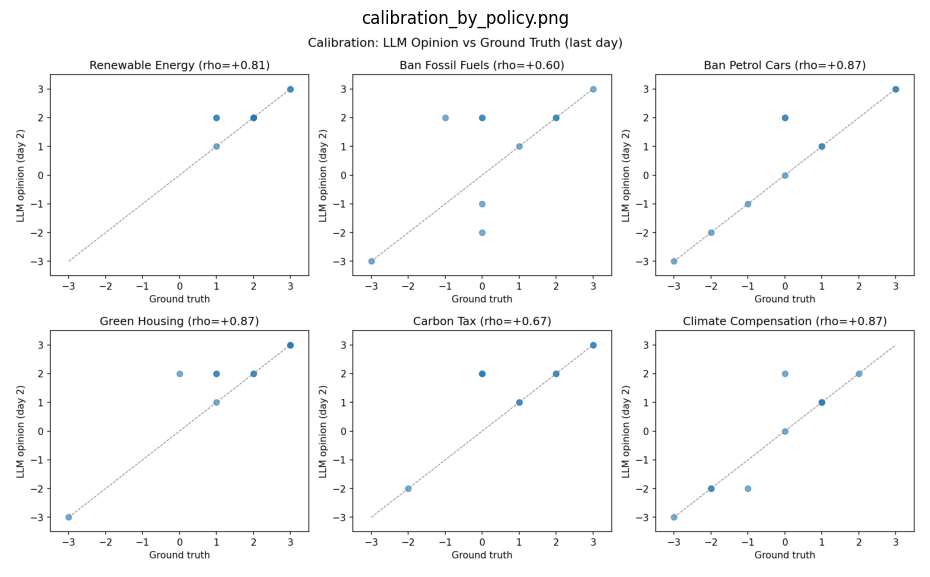

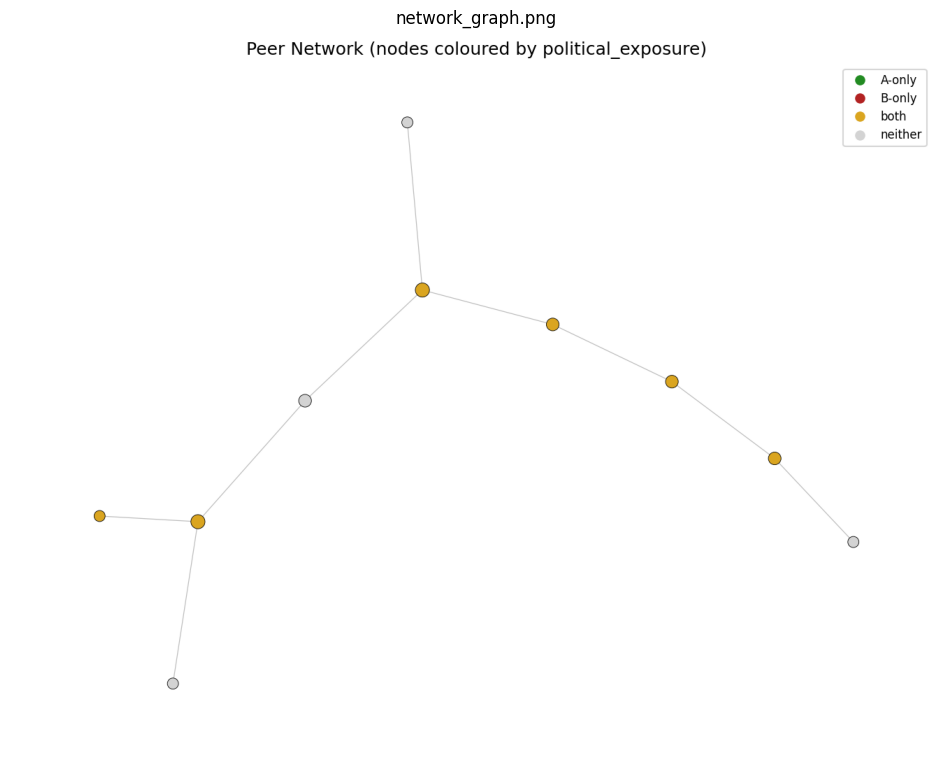

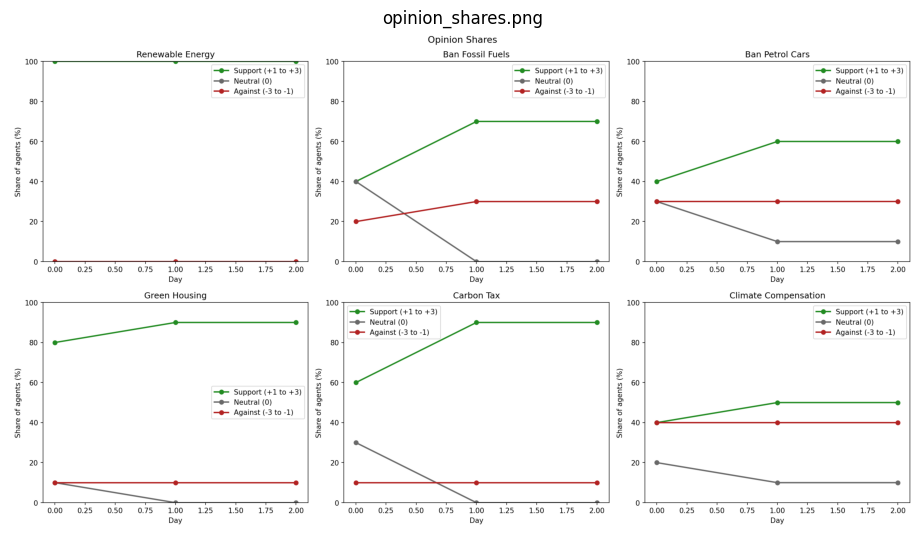

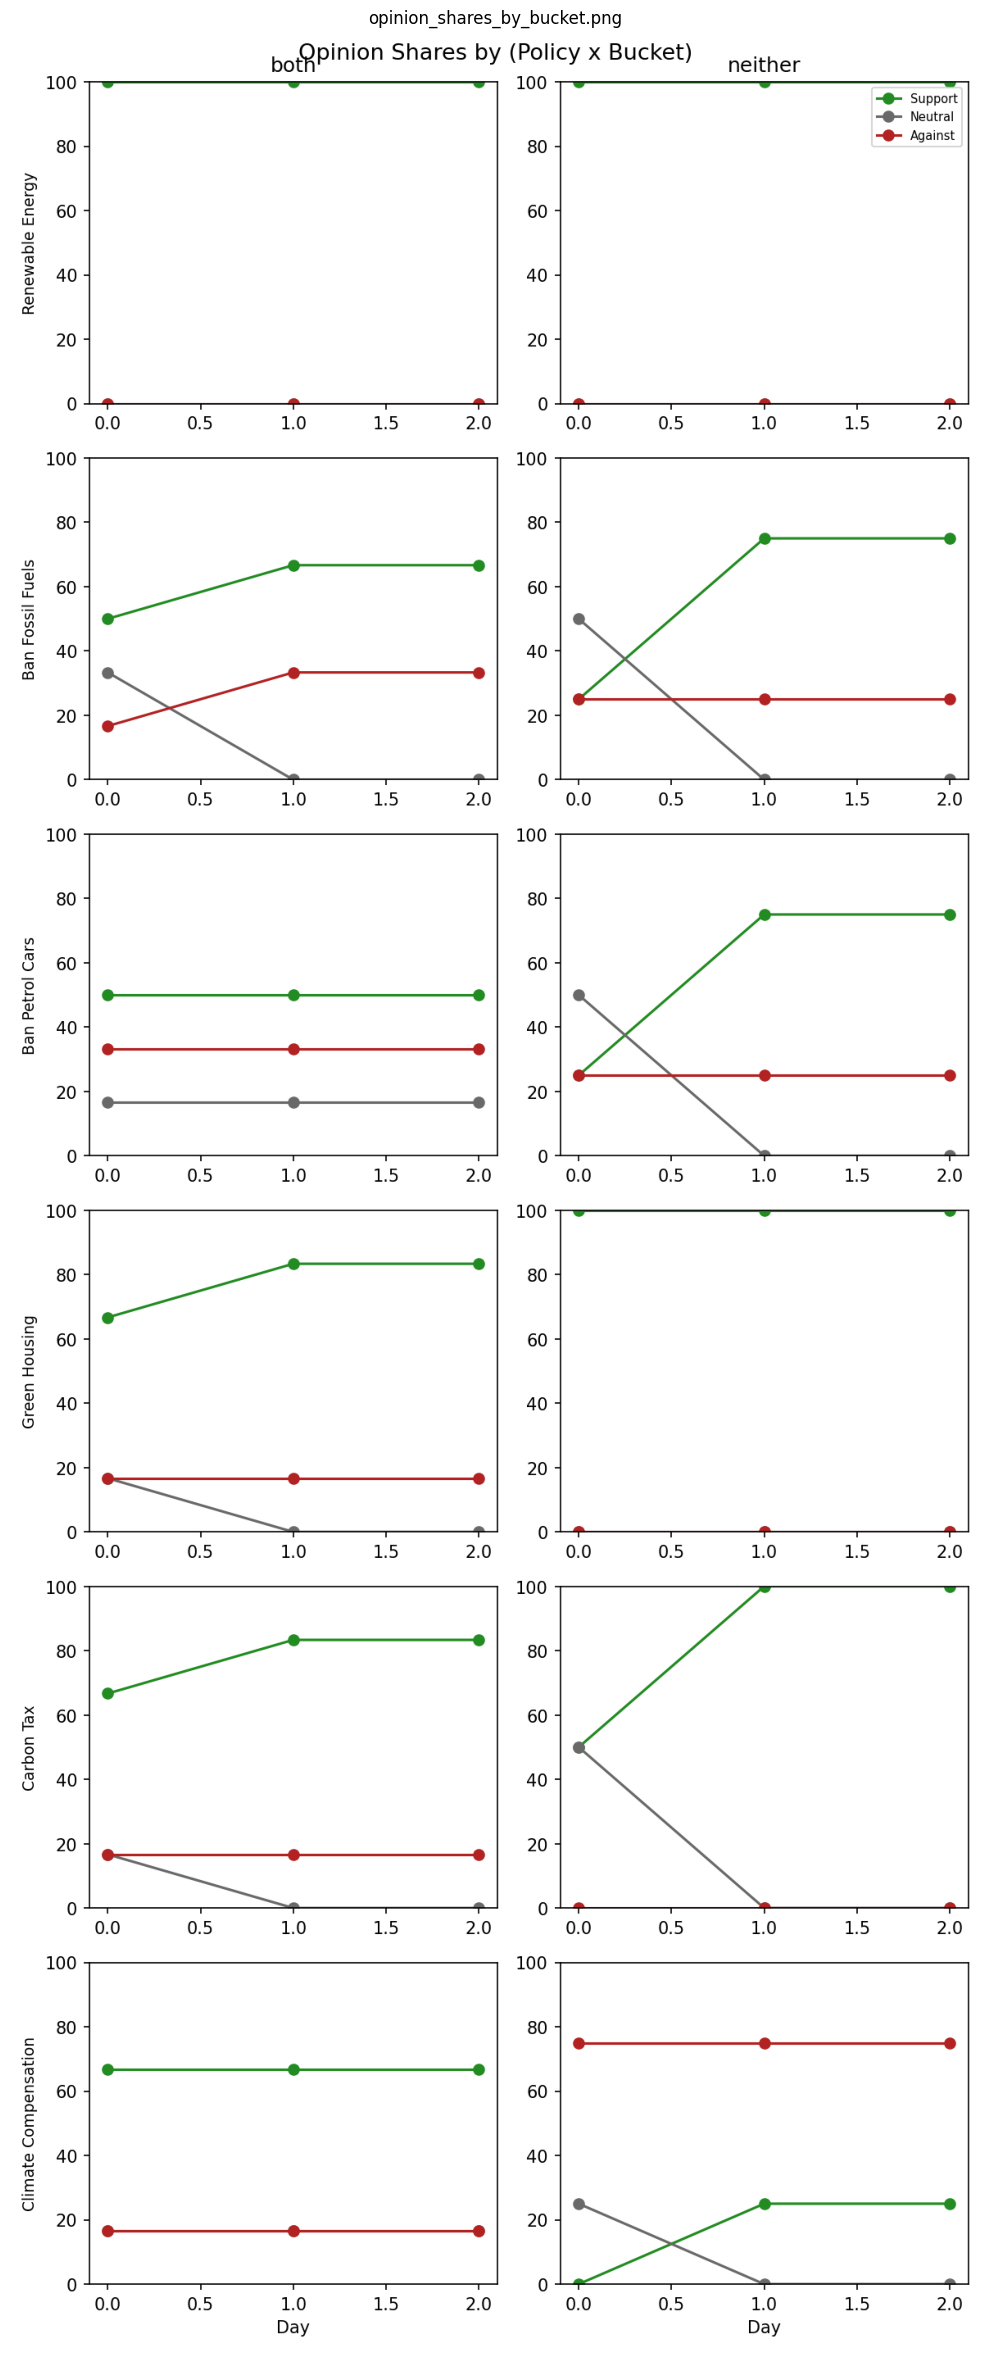

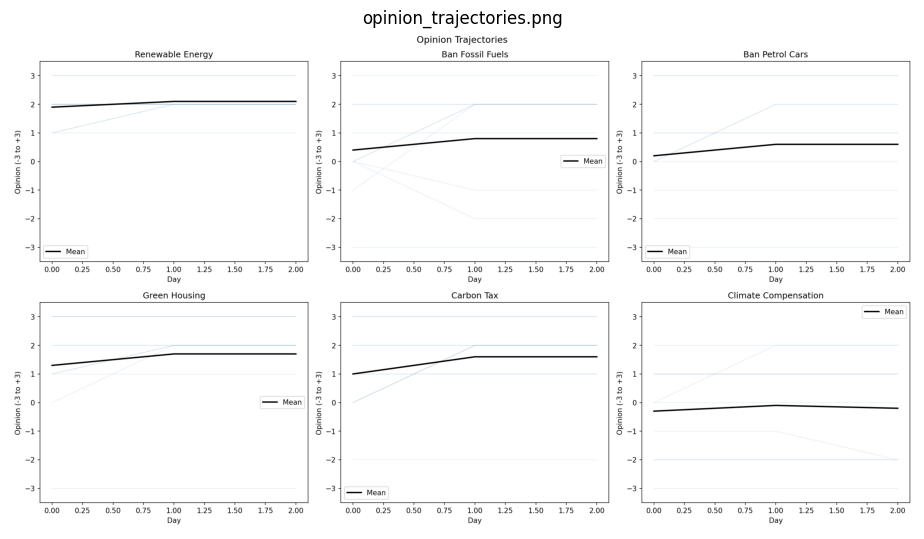

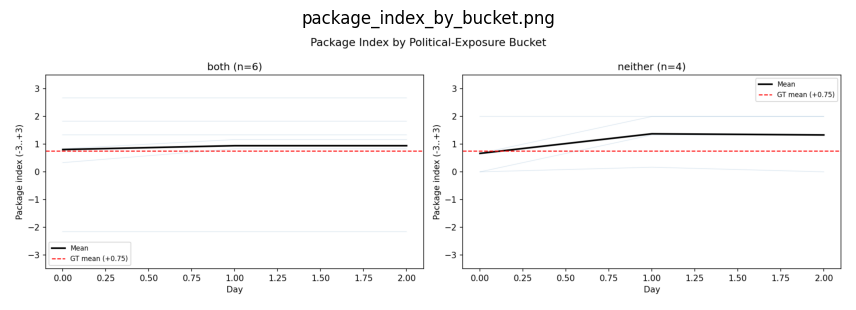

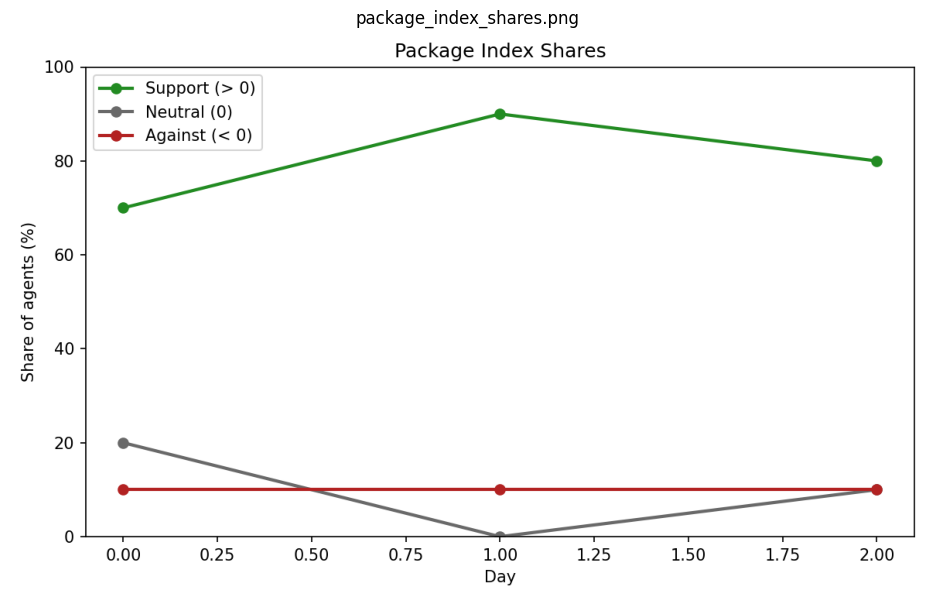

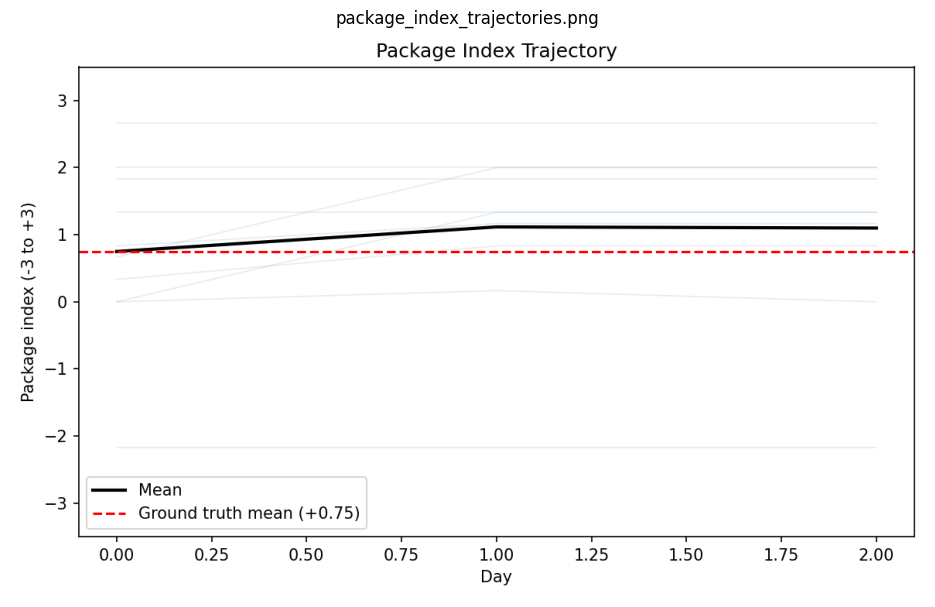

In [25]:
import matplotlib.image as mpimg

png_files = sorted(out_path.glob('*.png'))
print(f'PNG files: {len(png_files)}')

# Render each PNG inline at a readable size.
for p in png_files:
    img = mpimg.imread(p)
    h, w = img.shape[:2]
    fig_w = 10
    fig_h = fig_w * (h / w)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(img)
    ax.set_axis_off()
    ax.set_title(p.name)
    plt.tight_layout()
    plt.show()

## 11. Summary

If section 6 lists ~22 files (15+ CSVs, 3 JSON, 9 PNGs), section 7 shows non-empty frames for every key listed in `_RESULT_CSV_SCHEMAS`, section 8 prints non-empty bucket/timeline tables, section 9 reports `sim_step > 0` everywhere, and section 10 renders all 9 plots without `None`s — the v0.6 outputs expansion is wired correctly end-to-end.